In [ ]:
from google.colab import drive
drive.mount('/content/drive')8

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

base_path = "/content/drive/MyDrive/AI Diabetes Report Analyzer/02_OCR_Reports/Clinical_Laboratory_Test_Reports"

print(os.listdir(base_path))

['Train', 'Test']


In [ ]:
from collections import Counter

train_path = os.path.join(base_path, "Train")
test_path = os.path.join(base_path, "Test")

train_files = os.listdir(train_path)
test_files = os.listdir(test_path)

print("Train images:", len(train_files))
print("Test images:", len(test_files))

Train images: 138
Test images: 122


In [ ]:
train_extensions = Counter(
    os.path.splitext(file)[1].lower()
    for file in train_files
)

test_extensions = Counter(
    os.path.splitext(file)[1].lower()
    for file in test_files
)

print("Train formats:", train_extensions)
print("Test formats:", test_extensions)

Train formats: Counter({'.jpg': 138})
Test formats: Counter({'.jpg': 122})


train (55).jpg → (1654, 2337)


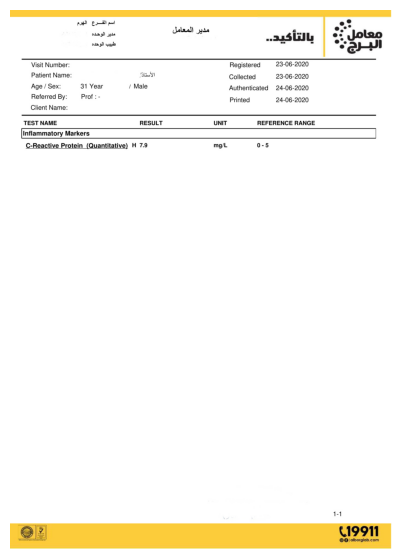

train (42).jpg → (1653, 2338)


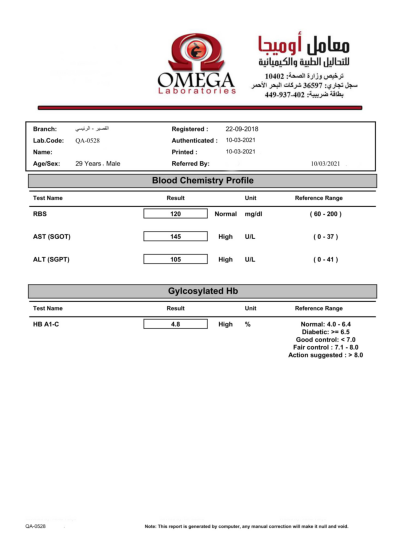

train (138).jpg → (1734, 2401)


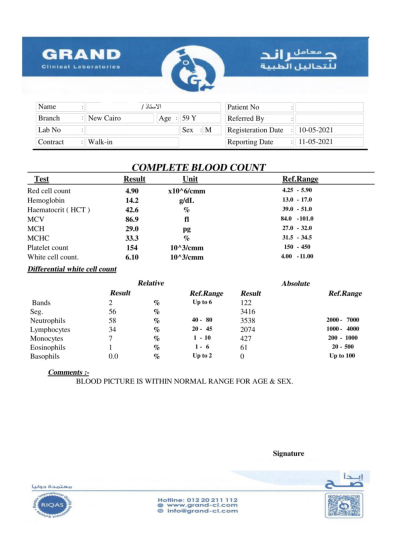

train (136).jpg → (1734, 2401)


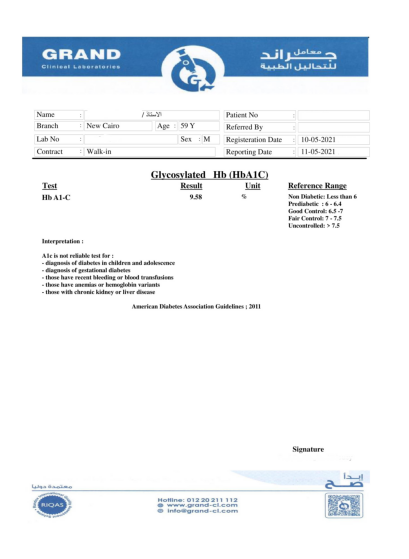

train (85).jpg → (1654, 2337)


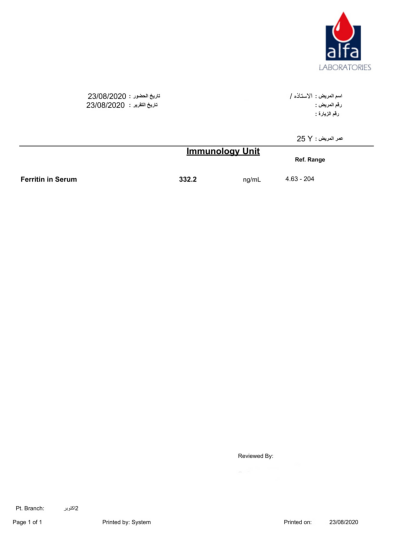

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt
import os
import random

sample_files = random.sample(train_files, 5)

for file in sample_files:
    img_path = os.path.join(train_path, file)
    img = Image.open(img_path)

    print(file, "→", img.size)

    plt.figure(figsize=(10, 7))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

Selected file: train (10).jpg


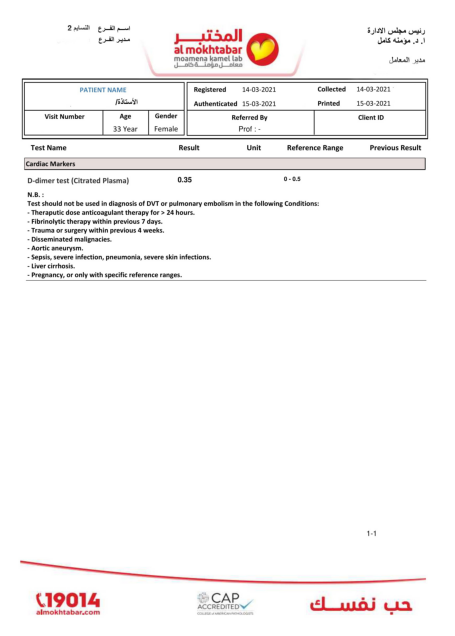

In [ ]:
sample_file = train_files[0]
sample_path = os.path.join(train_path, sample_file)

print("Selected file:", sample_file)

img = Image.open(sample_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
!sudo apt install tesseract-ocr -y
!pip install pytesseract

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


In [ ]:
import pytesseract

In [ ]:
text = pytesseract.image_to_string(img)

print(text)

2 ase gill al eoe | BAY) Qual Quasi)

Evndll jie ¥ alS Aiage a)
al mokhtabar
moamena kamel lab chalael) jate
J—olS G_ingo,J olen

PATIENT NAME Registered 14-03-2021 Collected 14-03-2021
[oa Authenticated 15-03-2021 Printed 15-03-2021

Visit Number Age Gender Referred By Client ID
33 Year Female Prof : -

Test Name Result Unit Reference Range Previous Result

 

 

 

Cardiac Markers

D-dimer test (Citrated Plasma) 0.35

N.B.:

Test should not be used in diagnosis of DVT or pulmonary embolism in the following Conditions:
- Theraputic dose anticoagulant therapy for > 24 hours.

- Fibrinolytic therapy within previous 7 days.

- Trauma or surgery within previous 4 weeks.

- Disseminated malignacies.

- Aortic aneurysm.

- Sepsis, severe infection, pneumonia, severe skin infections.

- Liver cirrhosis.

- Pregnancy, or only with specific reference ranges.

1-1

ee

almokhtabar.com

 



In [ ]:
import pytesseract
import os

keywords = [
    "hba1c",
    "glucose",
    "fasting",
    "blood sugar",
    "cholesterol",
    "triglycerides",
    "hdl",
    "ldl",
    "urine sugar"
]

matches = []

for file in train_files:
    image_path = os.path.join(train_path, file)

    text = pytesseract.image_to_string(image_path).lower()

    found = [word for word in keywords if word in text]

    if found:
        matches.append((file, found))

print("Reports with relevant keywords:", len(matches))

for file, found in matches[:20]:
    print(file, "→", found)

Reports with relevant keywords: 26
train (11).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (106).jpg → ['glucose']
train (101).jpg → ['glucose']
train (1).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (112).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (118).jpg → ['hba1c', 'glucose', 'fasting']
train (117).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (124).jpg → ['glucose']
train (13).jpg → ['glucose', 'fasting']
train (130).jpg → ['hba1c']
train (136).jpg → ['hba1c']
train (18).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (21).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (29).jpg → ['glucose', 'blood sugar']
train (28).jpg → ['glucose', 'blood sugar']
train (26).jpg → ['blood sugar']
train (44).jpg → ['glucose']
train (41).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (46).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
train (51).jpg → ['glucose', 'fasting']


In [ ]:
test_matches = []

for file in test_files:
    image_path = os.path.join(test_path, file)

    text = pytesseract.image_to_string(image_path).lower()

    found = [word for word in keywords if word in text]

    if found:
        test_matches.append((file, found))

print("Test reports with relevant keywords:", len(test_matches))

for file, found in test_matches:
    print(file, "→", found)

Test reports with relevant keywords: 20
test (104).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
test (111).jpg → ['glucose', 'fasting']
test (113).jpg → ['glucose']
test (105).jpg → ['glucose']
test (23).jpg → ['ldl']
test (15).jpg → ['glucose']
test (2).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
test (32).jpg → ['glucose', 'fasting']
test (4).jpg → ['glucose', 'fasting']
test (50).jpg → ['glucose']
test (29).jpg → ['ldl']
test (52).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
test (65).jpg → ['hba1c']
test (67).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
test (73).jpg → ['glucose']
test (74).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']
test (78).jpg → ['glucose', 'fasting']
test (89).jpg → ['hba1c', 'glucose']
test (97).jpg → ['cholesterol', 'triglycerides']
test (85).jpg → ['cholesterol', 'triglycerides', 'hdl', 'ldl']


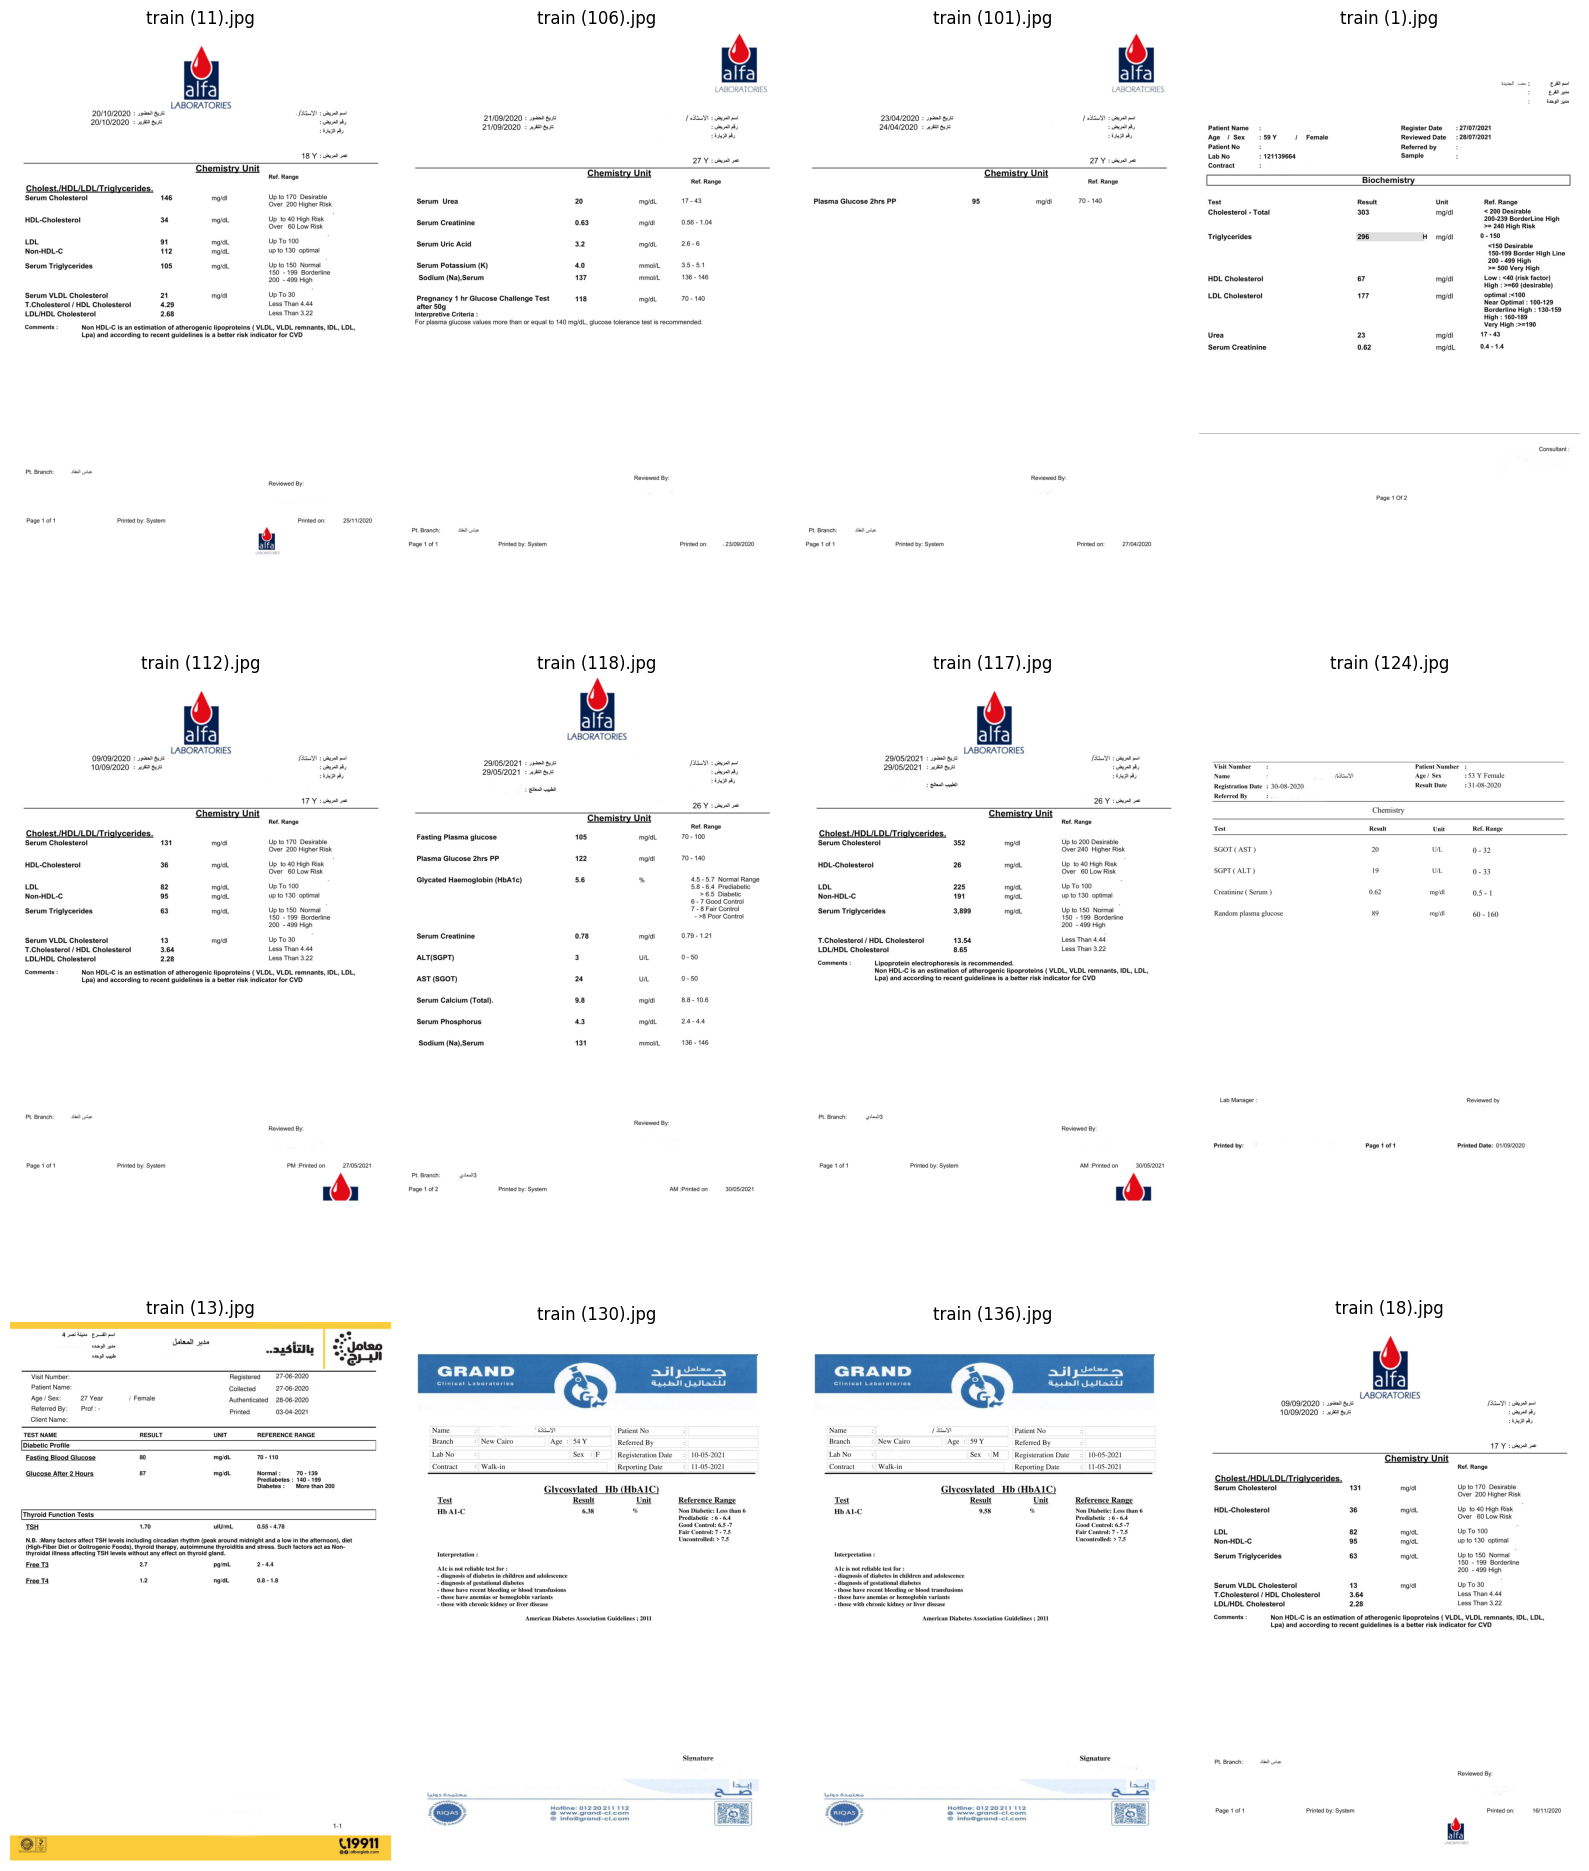

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os
import math

# Take the relevant Train reports
selected_files = [file for file, found in matches]

# Show first 12
selected_files = selected_files[:12]

fig, axes = plt.subplots(3, 4, figsize=(16, 20))
axes = axes.flatten()

for ax, file in zip(axes, selected_files):
    image_path = os.path.join(train_path, file)
    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(file)
    ax.axis("off")

plt.tight_layout()
plt.show()

File: train (118).jpg
Image size: (1654, 2337)


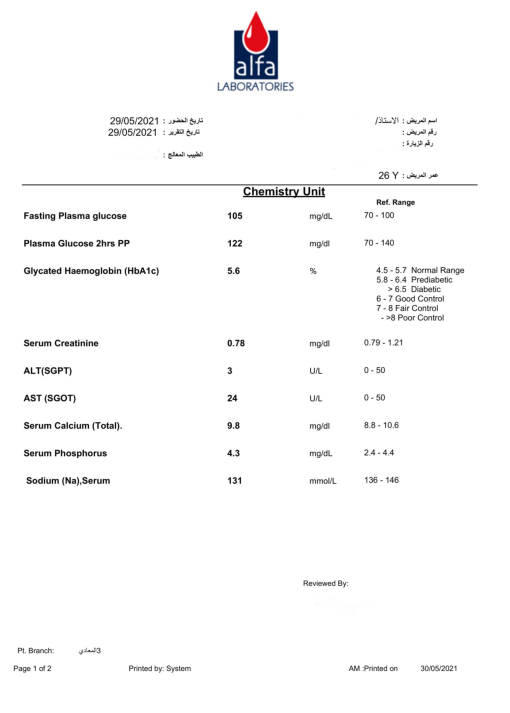

In [ ]:
file = "train (118).jpg"
image_path = os.path.join(train_path, file)

img = Image.open(image_path)

print("File:", file)
print("Image size:", img.size)

plt.figure(figsize=(12, 9))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
text = pytesseract.image_to_string(img)

print(text)

LABORATORIES

29/05/2021 : sx Qui [3GGNV saya aul
29/05/2021: it) qu 2 Uauall aly
1 BGS aby
1 Giles!) Guybl
26 Y : call we
Chemistry Unit
Ref. Range
Fasting Plasma glucose 105 mg/dL 70 - 100
Plasma Glucose 2hrs PP 122 mg/dl 70 - 140
Glycated Haemoglobin (HbA1c) 5.6 % 4.5 -5.7 Normal Range
5.8 - 6.4 Prediabetic
>6.5 Diabetic

6 - 7 Good Control
7 - 8 Fair Control
- >8 Poor Control

Serum Creatinine 0.78 mg/dl 0.79 - 1.21

ALT(SGPT) 3 U/L 0-50
AST (SGOT) 24 U/L 0-50
Serum Calcium (Total). 9.8 mg/dl 8.8 - 10.6
Serum Phosphorus 4.3 mg/dL 24-44
Sodium (Na),Serum 131 mmol/L 136 - 146

Reviewed By:
Pt. Branch: gradl3

Page 1 of 2 Printed by: System AM :Printed on 30/05/2021



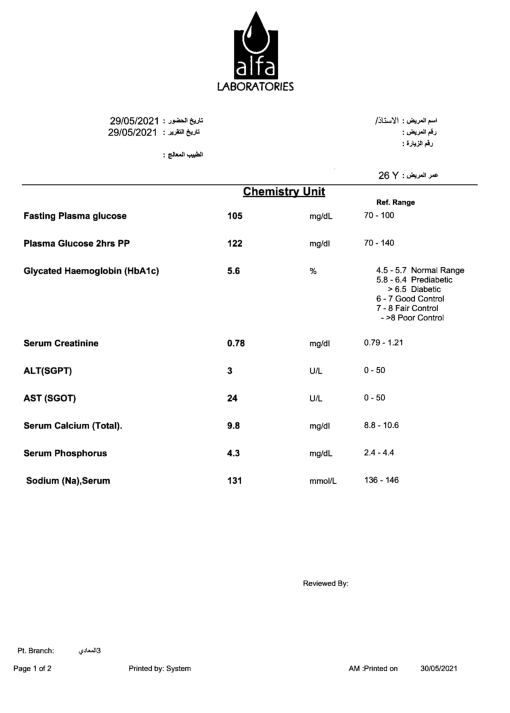

In [ ]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Convert PIL image to OpenCV format
image_cv = np.array(img)

# Convert to grayscale
gray = cv2.cvtColor(image_cv, cv2.COLOR_RGB2GRAY)

# Apply thresholding
_, thresh = cv2.threshold(
    gray,
    180,
    255,
    cv2.THRESH_BINARY
)

# Display preprocessed image
plt.figure(figsize=(12, 9))
plt.imshow(thresh, cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
processed_text = pytesseract.image_to_string(thresh)

print(processed_text)

LABORATORIES

29/05/2021 : seat G8
29/05/2021: xii @5

y gual uygall
Chemistry Unit

Fasting Plasma glucose 105 mg/dL
Plasma Glucose 2hrs PP 122 mg/dl
Glycated Haemoglobin (HbA1c) 5.6 %
Serum Creatinine 0.78 mg/dl
ALT(SGPT) 3 UIL
AST (SGOT) 24 U/L
Serum Calcium (Total). 9.8 mg/dl
Serum Phosphorus 43 mg/dL
Sodium (Na),Serum 131 mmol/L

Reviewed By:

Pt. Branch: giladi3

Page 1 of 2 Printed by: System

[SN + lapel al
1 oezzall

+ Bul aby
26 Y : call we

Ref. Range
70 - 100

70 - 140

4.5 -5.7 Normal Range
5.8 -6.4 Prediabetic
>6.5 Diabetic
6 - 7 Good Control
7 - 8 Fair Control
- >8 Poor Control

0.79 - 1.21

8.8 - 10.6

24-44

136 - 146

AM :Printed on 30/05/2021



In [ ]:
import re

text = pytesseract.image_to_string(img)

print(text)

LABORATORIES

29/05/2021 : sx Qui [3GGNV saya aul
29/05/2021: it) qu 2 Uauall aly
1 BGS aby
1 Giles!) Guybl
26 Y : call we
Chemistry Unit
Ref. Range
Fasting Plasma glucose 105 mg/dL 70 - 100
Plasma Glucose 2hrs PP 122 mg/dl 70 - 140
Glycated Haemoglobin (HbA1c) 5.6 % 4.5 -5.7 Normal Range
5.8 - 6.4 Prediabetic
>6.5 Diabetic

6 - 7 Good Control
7 - 8 Fair Control
- >8 Poor Control

Serum Creatinine 0.78 mg/dl 0.79 - 1.21

ALT(SGPT) 3 U/L 0-50
AST (SGOT) 24 U/L 0-50
Serum Calcium (Total). 9.8 mg/dl 8.8 - 10.6
Serum Phosphorus 4.3 mg/dL 24-44
Sodium (Na),Serum 131 mmol/L 136 - 146

Reviewed By:
Pt. Branch: gradl3

Page 1 of 2 Printed by: System AM :Printed on 30/05/2021



In [ ]:
import re

# Raw OCR text
text = pytesseract.image_to_string(img)

# Extract Fasting Plasma Glucose
fasting_match = re.search(
    r"Fasting Plasma glucose\s+(\d+(?:\.\d+)?)\s*(mg/dL|mg/dl)",
    text,
    re.IGNORECASE
)

# Extract 2-hour Post-Prandial Glucose
pp_match = re.search(
    r"Plasma Glucose 2hrs PP\s+(\d+(?:\.\d+)?)\s*(mg/dL|mg/dl)",
    text,
    re.IGNORECASE
)

# Extract HbA1c
hba1c_match = re.search(
    r"Glycated Haemoglobin \(HbA1c\)\s+(\d+(?:\.\d+)?)\s*%",
    text,
    re.IGNORECASE
)

print("Fasting Glucose:", fasting_match.groups() if fasting_match else "Not found")
print("2hr PP Glucose:", pp_match.groups() if pp_match else "Not found")
print("HbA1c:", hba1c_match.groups() if hba1c_match else "Not found")

Fasting Glucose: ('105', 'mg/dL')
2hr PP Glucose: ('122', 'mg/dl')
HbA1c: ('5.6',)


In [ ]:
extracted_data = {
    "Fasting Plasma Glucose": {
        "value": 105,
        "unit": "mg/dL"
    },
    "Plasma Glucose 2hrs PP": {
        "value": 122,
        "unit": "mg/dL"
    },
    "HbA1c": {
        "value": 5.6,
        "unit": "%"
    }
}

print(extracted_data)

{'Fasting Plasma Glucose': {'value': 105, 'unit': 'mg/dL'}, 'Plasma Glucose 2hrs PP': {'value': 122, 'unit': 'mg/dL'}, 'HbA1c': {'value': 5.6, 'unit': '%'}}
